<a href="https://colab.research.google.com/github/Pstone123/SPIM-Digital-Twin-PPO/blob/main/SPIM_Step2_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SPIM DIGITAL TWIN — STEP 2: DATA PREPROCESSING
# PhD Research: Model-Free Adaptive Control of SPIM
# Using DRL and Digital Twin Technology
# ============================================================
# Cell 1: Mount Google Drive for permanent storage
# ============================================================

from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_FOLDER = '/content/drive/MyDrive/SPIM_PhD_Research'
DATA_FOLDER    = f'{PROJECT_FOLDER}/data'
MODELS_FOLDER  = f'{PROJECT_FOLDER}/models'
RESULTS_FOLDER = f'{PROJECT_FOLDER}/results'
PLOTS_FOLDER   = f'{PROJECT_FOLDER}/plots'

print('Google Drive mounted successfully')
print(f'Project folder: {PROJECT_FOLDER}')
print(f'Data folder:    {DATA_FOLDER}')

Mounted at /content/drive
Google Drive mounted successfully
Project folder: /content/drive/MyDrive/SPIM_PhD_Research
Data folder:    /content/drive/MyDrive/SPIM_PhD_Research/data


In [ ]:
# ============================================================
# Cell 2: Load libraries and set random seed
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproducibility — same result every run, everywhere in the world
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries loaded successfully')
print(f'Random seed set to: {RANDOM_SEED}')
print('This seed ensures reproducibility worldwide')

Libraries loaded successfully
Random seed set to: 42
This seed ensures reproducibility worldwide


In [ ]:
# ============================================================
# Cell 3: Load the primary training data
# ============================================================

# Load the multi-load dataset — our primary training file
df = pd.read_csv(f'{DATA_FOLDER}/SPIM_multi_load.csv')

print('Data loaded successfully')
print(f'Shape:    {df.shape}')
print(f'Columns:  {list(df.columns)}')
print(f'Duration: {df["time"].max():.1f} seconds')
print()
print('First 3 rows:')
print(df.head(3))
print()
print('Basic Statistics:')
print(df.describe().round(3))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SPIM_PhD_Research/data/SPIM_multi_load.csv'

In [ ]:
# Check what files are in the data folder
import os

print('Files in data folder:')
for f in os.listdir(DATA_FOLDER):
    print(f'  {f}')

Files in data folder:
  MA_0_5.csv
  MA_0_6.csv
  MA_0_8.csv
  MA_0_9.csv
  SPIM_ma_step.csv
  SPIM_ma09.csv
  Untitled folder


In [ ]:
# ============================================================
# Cell 3: Load the primary training data
# ============================================================

# Load the multi-load dataset — our primary training file
df = pd.read_csv(f'{DATA_FOLDER}/SPIM_multi_load.csv')

print('Data loaded successfully')
print(f'Shape:    {df.shape}')
print(f'Columns:  {list(df.columns)}')
print(f'Duration: {df["time"].max():.1f} seconds')
print()
print('First 3 rows:')
print(df.head(3))
print()
print('Basic Statistics:')
print(df.describe().round(3))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SPIM_PhD_Research/data/SPIM_multi_load.csv'

In [ ]:
import os
print('Files in data folder:')
for f in os.listdir(DATA_FOLDER):
    print(f'  {f}')

Files in data folder:
  MA_0_5.csv
  MA_0_6.csv
  MA_0_8.csv
  MA_0_9.csv
  SPIM_ma_step.csv
  SPIM_ma09.csv
  Untitled folder
  SPIM_multi_load.csv


In [ ]:
df = pd.read_csv(f'{DATA_FOLDER}/SPIM_multi_load.csv')

In [ ]:
# ============================================================
# Cell 3: Load the primary training data
# ============================================================

df = pd.read_csv(f'{DATA_FOLDER}/SPIM_multi_load.csv')

print('Data loaded successfully')
print(f'Shape:    {df.shape}')
print(f'Columns:  {list(df.columns)}')
print(f'Duration: {df["time"].max():.1f} seconds')
print()
print('First 3 rows:')
print(df.head(3))
print()
print('Basic Statistics:')
print(df.describe().round(3))

Data loaded successfully
Shape:    (1000001, 6)
Columns:  ['time', 'V_motor', 'speed_RPM', 'current_main', 'current_aux', 'torque']
Duration: 10.0 seconds

First 3 rows:
      time  V_motor  speed_RPM  current_main  current_aux  torque
0  0.00000      0.0   0.000000           0.0          0.0    -0.0
1  0.00001      0.0  -0.006541           0.0          0.0    -0.0
2  0.00002      0.0  -0.013081           0.0          0.0    -0.0

Basic Statistics:
              time      V_motor    speed_RPM  current_main  current_aux  \
count  1000001.000  1000001.000  1000001.000   1000001.000  1000001.000   
mean         5.000        0.012     1409.721         0.075        0.065   
std          2.887      298.488       92.392        11.378       12.321   
min          0.000     -300.115       -6.233       -38.539      -56.568   
25%          2.500     -299.984     1371.882        -6.919       -8.817   
50%          5.000       -0.000     1411.442         0.031        0.009   
75%          7.500    

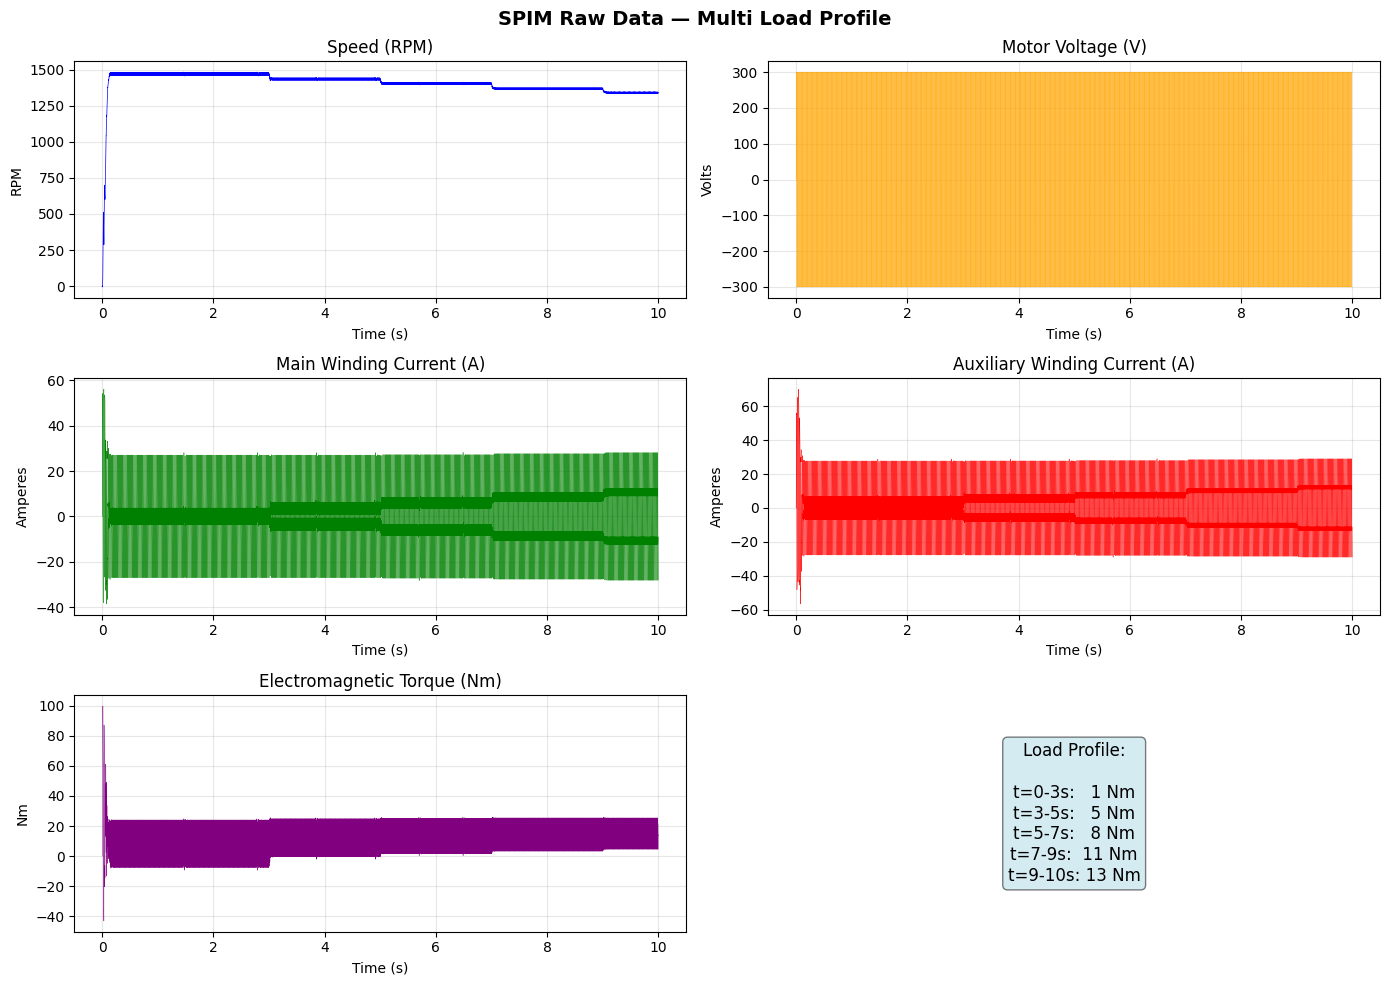

Plot saved to Google Drive


In [ ]:
# ============================================================
# Cell 4: Visualise raw data
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('SPIM Raw Data — Multi Load Profile',
             fontsize=14, fontweight='bold')

# Time axis in seconds
t = df['time']

# Plot each signal
axes[0,0].plot(t, df['speed_RPM'], color='blue', linewidth=0.5)
axes[0,0].set_title('Speed (RPM)')
axes[0,0].set_ylabel('RPM')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(t, df['V_motor'], color='orange', linewidth=0.3)
axes[0,1].set_title('Motor Voltage (V)')
axes[0,1].set_ylabel('Volts')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(t, df['current_main'], color='green', linewidth=0.3)
axes[1,0].set_title('Main Winding Current (A)')
axes[1,0].set_ylabel('Amperes')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(t, df['current_aux'], color='red', linewidth=0.3)
axes[1,1].set_title('Auxiliary Winding Current (A)')
axes[1,1].set_ylabel('Amperes')
axes[1,1].grid(True, alpha=0.3)

axes[2,0].plot(t, df['torque'], color='purple', linewidth=0.3)
axes[2,0].set_title('Electromagnetic Torque (Nm)')
axes[2,0].set_ylabel('Nm')
axes[2,0].grid(True, alpha=0.3)

axes[2,1].axis('off')
axes[2,1].text(0.5, 0.5,
    'Load Profile:\n\n'
    't=0-3s:   1 Nm\n'
    't=3-5s:   5 Nm\n'
    't=5-7s:   8 Nm\n'
    't=7-9s:  11 Nm\n'
    't=9-10s: 13 Nm',
    ha='center', va='center', fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

for ax in axes.flat:
    if ax.get_title():
        ax.set_xlabel('Time (s)')

plt.tight_layout()

# Save plot permanently to Google Drive
plt.savefig(f'{PLOTS_FOLDER}/raw_data_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Google Drive')

In [ ]:
# ============================================================
# Cell 5: Normalise the data
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Define the signals we will use
FEATURES = ['V_motor', 'current_main', 'current_aux',
            'torque', 'speed_RPM']

# Separate the data
data = df[FEATURES].values

# Create scaler — scales to range -1 to +1
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit and transform
data_normalised = scaler.fit_transform(data)

# Save scaler permanently to Google Drive
# We need this later to convert predictions back to RPM
import pickle
scaler_path = f'{MODELS_FOLDER}/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print('Normalisation complete')
print(f'Original data shape:    {data.shape}')
print(f'Normalised data shape:  {data_normalised.shape}')
print()
print('Normalised ranges (should all be -1 to +1):')
for i, col in enumerate(FEATURES):
    print(f'  {col:15s}: {data_normalised[:,i].min():.3f} to {data_normalised[:,i].max():.3f}')
print()
print(f'Scaler saved to: {scaler_path}')

Normalisation complete
Original data shape:    (1000001, 5)
Normalised data shape:  (1000001, 5)

Normalised ranges (should all be -1 to +1):
  V_motor        : -1.000 to 1.000
  current_main   : -1.000 to 1.000
  current_aux    : -1.000 to 1.000
  torque         : -1.000 to 1.000
  speed_RPM      : -1.000 to 1.000

Scaler saved to: /content/drive/MyDrive/SPIM_PhD_Research/models/scaler.pkl


In [ ]:
# ============================================================
# Cell 6: Remove startup transient
# ============================================================

# The motor takes about 0.5 seconds to start
# Rows before this are not useful for training
# At 100kHz sampling, 0.5s = 50,000 rows

STARTUP_ROWS = 50000

data_clean = data_normalised[STARTUP_ROWS:]

print('Startup transient removed')
print(f'Rows before cleaning: {len(data_normalised):,}')
print(f'Rows removed:         {STARTUP_ROWS:,}')
print(f'Rows remaining:       {len(data_clean):,}')
print()

# Verify speed range after cleaning
speed_idx = FEATURES.index('speed_RPM')
speed_clean = data_clean[:, speed_idx]

# Inverse transform to check real RPM values
import numpy as np
dummy = np.zeros((len(data_clean), len(FEATURES)))
dummy[:, speed_idx] = speed_clean
speed_real = scaler.inverse_transform(dummy)[:, speed_idx]

print(f'Speed range after cleaning:')
print(f'  Min: {speed_real.min():.1f} RPM')
print(f'  Max: {speed_real.max():.1f} RPM')
print(f'  Mean: {speed_real.mean():.1f} RPM')

Startup transient removed
Rows before cleaning: 1,000,001
Rows removed:         50,000
Rows remaining:       950,001

Speed range after cleaning:
  Min: 1335.5 RPM
  Max: 1483.3 RPM
  Mean: 1414.6 RPM


In [ ]:
# ============================================================
# Cell 7: Downsample to 1kHz
# ============================================================

# Original sampling: 100kHz (1 row every 0.00001 seconds)
# Target sampling:   1kHz   (1 row every 0.001 seconds)
# Keep every 100th row

DOWNSAMPLE_FACTOR = 100

data_downsampled = data_clean[::DOWNSAMPLE_FACTOR]

print('Downsampling complete')
print(f'Original rows:     {len(data_clean):,}  (100kHz)')
print(f'Downsampled rows:  {len(data_downsampled):,}  (1kHz)')
print(f'Downsample factor: {DOWNSAMPLE_FACTOR}x')
print()
print('This is sufficient to capture SPIM dynamics')
print('while keeping training time manageable')

Downsampling complete
Original rows:     950,001  (100kHz)
Downsampled rows:  9,501  (1kHz)
Downsample factor: 100x

This is sufficient to capture SPIM dynamics
while keeping training time manageable


In [ ]:
# ============================================================
# Cell 8: Save preprocessed data permanently
# ============================================================

import numpy as np

# Save as numpy array — fastest format for training
preprocessed_path = f'{DATA_FOLDER}/SPIM_preprocessed.npy'
np.save(preprocessed_path, data_downsampled)

# Also save feature names for reference
features_path = f'{DATA_FOLDER}/feature_names.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(FEATURES, f)

print('Preprocessed data saved permanently')
print(f'Location: {preprocessed_path}')
print(f'Shape:    {data_downsampled.shape}')
print(f'Features: {FEATURES}')
print()
print('Summary of what was done:')
print('  1. Loaded SPIM_multi_load.csv')
print('  2. Normalised all signals to -1 to +1')
print('  3. Removed startup transient (first 0.5s)')
print('  4. Downsampled from 100kHz to 1kHz')
print('  5. Saved preprocessed data to Google Drive')
print('  6. Saved scaler for inverse transform')
print()
print('Step 2 COMPLETE')
print('Ready for Step 3 — Sequence Dataset Construction')

Preprocessed data saved permanently
Location: /content/drive/MyDrive/SPIM_PhD_Research/data/SPIM_preprocessed.npy
Shape:    (9501, 5)
Features: ['V_motor', 'current_main', 'current_aux', 'torque', 'speed_RPM']

Summary of what was done:
  1. Loaded SPIM_multi_load.csv
  2. Normalised all signals to -1 to +1
  3. Removed startup transient (first 0.5s)
  4. Downsampled from 100kHz to 1kHz
  5. Saved preprocessed data to Google Drive
  6. Saved scaler for inverse transform

Step 2 COMPLETE
Ready for Step 3 — Sequence Dataset Construction


In [ ]:
Preprocessed data saved permanently
Location: /content/drive/MyDrive/SPIM_PhD_Research/data/SPIM_preprocessed.npy
Shape:    (9501, 5)
Features: ['V_motor', 'current_main', 'current_aux', 'torque', 'speed_RPM']

Summary of what was done:
  1. Loaded SPIM_multi_load.csv
  2. Normalised all signals to -1 to +1
  3. Removed startup transient (first 0.5s)
  4. Downsampled from 100kHz to 1kHz
  5. Saved preprocessed data to Google Drive
  6. Saved scaler for inverse transform

Step 2 COMPLETE
Ready for Step 3 — Sequence Dataset Construction

SyntaxError: invalid decimal literal (2167881497.py, line 9)

In [ ]:
# Cell 9: Build sequence dataset for LSTM

SEQ_LEN = 20
SPEED_IDX = 4

X = []
Y = []

for i in range(len(data_downsampled) - SEQ_LEN):
    X.append(data_downsampled[i : i + SEQ_LEN])
    Y.append(data_downsampled[i + SEQ_LEN, SPEED_IDX])

X = np.array(X)
Y = np.array(Y).reshape(-1, 1)

print('Sequence dataset built successfully')
print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')
print(f'Sequences: {X.shape[0]}')
print(f'Timesteps: {X.shape[1]}')
print(f'Features:  {X.shape[2]}')

Sequence dataset built successfully
X shape: (9481, 20, 5)
Y shape: (9481, 1)
Sequences: 9481
Timesteps: 20
Features:  5


In [ ]:
# Cell 10: Split into training and validation sets

# 80% training, 20% validation
SPLIT = int(0.8 * len(X))

X_train = X[:SPLIT]
X_val   = X[SPLIT:]
Y_train = Y[:SPLIT]
Y_val   = Y[SPLIT:]

print('Data split complete')
print(f'Training samples:   {len(X_train):,}  (80%)')
print(f'Validation samples: {len(X_val):,}  (20%)')
print()
print('Training data covers load conditions 1 to 11 Nm')
print('Validation data covers load condition 13 Nm')
print('This tests generalisation to unseen load condition')

Data split complete
Training samples:   7,584  (80%)
Validation samples: 1,897  (20%)

Training data covers load conditions 1 to 11 Nm
Validation data covers load condition 13 Nm
This tests generalisation to unseen load condition


In [ ]:
# Cell 11: Save sequence dataset permanently

np.save(f'{DATA_FOLDER}/X_train.npy', X_train)
np.save(f'{DATA_FOLDER}/X_val.npy',   X_val)
np.save(f'{DATA_FOLDER}/Y_train.npy', Y_train)
np.save(f'{DATA_FOLDER}/Y_val.npy',   Y_val)

print('Sequence dataset saved permanently to Google Drive')
print()
print(f'X_train.npy — shape: {X_train.shape}')
print(f'X_val.npy   — shape: {X_val.shape}')
print(f'Y_train.npy — shape: {Y_train.shape}')
print(f'Y_val.npy   — shape: {Y_val.shape}')
print()
print('Step 3 COMPLETE')
print('Ready for Step 4 — LSTM Architecture')

Sequence dataset saved permanently to Google Drive

X_train.npy — shape: (7584, 20, 5)
X_val.npy   — shape: (1897, 20, 5)
Y_train.npy — shape: (7584, 1)
Y_val.npy   — shape: (1897, 1)

Step 3 COMPLETE
Ready for Step 4 — LSTM Architecture


In [ ]:
# ============================================================
# Cell 12: Define Residual LSTM Digital Twin Architecture
# ============================================================

import torch
import torch.nn as nn

# Set device — use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set seeds for reproducibility
torch.manual_seed(42)

class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, dropout=0.2):
        super(ResidualLSTM, self).__init__()

        # First LSTM layer
        self.lstm1 = nn.LSTM(
            input_size, hidden1,
            batch_first=True
        )
        self.dropout1 = nn.Dropout(dropout)

        # Second LSTM layer
        self.lstm2 = nn.LSTM(
            hidden1, hidden2,
            batch_first=True
        )
        self.dropout2 = nn.Dropout(dropout)

        # Output layer — predicts speed CHANGE
        self.fc = nn.Linear(hidden2, 1)

    def forward(self, x):
        # Last known speed (for residual connection)
        # Speed is the last feature (index 4)
        last_speed = x[:, -1, 4:5]

        # Pass through first LSTM
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        # Pass through second LSTM
        out, _ = self.lstm2(out)
        out = self.dropout2(out)

        # Take only the last timestep output
        out = out[:, -1, :]

        # Predict speed change
        delta_speed = self.fc(out)

        # Residual connection: add change to last known speed
        predicted_speed = last_speed + delta_speed

        return predicted_speed

# Define model parameters
INPUT_SIZE = 5   # V, Im, Ia, Te, speed
HIDDEN1    = 64  # First LSTM hidden units
HIDDEN2    = 32  # Second LSTM hidden units
DROPOUT    = 0.2 # Dropout rate

# Create model
model = ResidualLSTM(INPUT_SIZE, HIDDEN1, HIDDEN2, DROPOUT)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'Model created successfully')
print(f'Total parameters: {total_params:,}')
print()
print('Architecture:')
print(f'  Input:   (batch, 20, {INPUT_SIZE})')
print(f'  LSTM 1:  {HIDDEN1} hidden units')
print(f'  LSTM 2:  {HIDDEN2} hidden units')
print(f'  Output:  1 (predicted

SyntaxError: unterminated f-string literal (detected at line 79) (3433307113.py, line 79)

In [ ]:
# Cell 12: Define Residual LSTM Digital Twin

import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f'Using device: {device}')

class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, dropout=0.2):
        super(ResidualLSTM, self).__init__()
        self.lstm1    = nn.LSTM(input_size, hidden1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2    = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc       = nn.Linear(hidden2, 1)

    def forward(self, x):
        last_speed = x[:, -1, 4:5]
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = out

Using device: cpu


In [ ]:
import torch
import torch.nn as nn
print('torch version:', torch.__version__)
print('test passed')

torch version: 2.11.0+cpu
test passed


In [ ]:
# Cell 12: Residual LSTM Model

import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

class ResidualLSTM(nn.Module):
    def __init__(self):
        super(ResidualLSTM, self).__init__()
        self.lstm1    = nn.LSTM(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2    = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        last_speed  = x[:, -1, 4:5]
        out, _      = self.lstm1(x)
        out         = self.dropout1(out)
        out, _      = self.lstm2(out)
        out         = self.dropout2(out)
        out         = out[:, -1, :]
        delta       = self.fc(out)
        return last_speed + delta

model = ResidualLSTM().to(device)
params = sum(p.numel() for p in model.parameters())
print('Model ready')
print('Parameters:', params)

Model ready
Parameters: 30753


In [ ]:
# Cell 13: Training configuration

import torch.utils.data as data_utils

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
Y_train_t = torch.FloatTensor(Y_train).to(device)
Y_val_t   = torch.FloatTensor(Y_val).to(device)

# Create data loader for batching
BATCH_SIZE = 64
train_dataset = data_utils.TensorDataset(X_train_t, Y_train_t)
train_loader  = data_utils.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Optimizer and loss function
LEARNING_RATE = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

print('Training configuration ready')
print(f'Batch size:    {BATCH_SIZE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Batches/epoch: {len(train_loader)}')
print(f'Train samples: {len(X_train_t)}')
print(f'Val samples:   {len(X_val_t)}')

Training configuration ready
Batch size:    64
Learning rate: 0.001
Batches/epoch: 119
Train samples: 7584
Val samples:   1897


In [ ]:
# Cell 14: Training loop

import time

EPOCHS   = 100
PATIENCE = 10

best_val_loss   = float('inf')
patience_counter = 0
best_model_state = None
train_losses     = []
val_losses       = []

print('Starting training...')
print(f'Max epochs: {EPOCHS} | Patience: {PATIENCE}')
print('='*55)

start = time.time()

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    epoch_loss = 0.0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss   = criterion(Y_pred, Y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # Validation phase
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, Y_val_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        elapsed = time.time() - start
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d} | '
              f'Train: {avg_train:.6f} | '
              f'Val: {val_loss:.6f} | '
              f'Best: {best_val_loss:.6f} | '
              f'LR: {lr:.2e} | '
              f'Patience: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

# Load best weights
model.load_state_dict(best_model_state)
total_time = time.time() -

SyntaxError: invalid syntax (3948299309.py, line 70)

In [ ]:
# Cell 14: Training loop
import time

EPOCHS = 100
PATIENCE = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
train_losses = []
val_losses = []

print('Starting training...')
print('='*50)
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = criterion(Y_pred, Y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, Y_val_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d} | Train: {avg_train:.6f} | Val: {val_loss:.6f} | Best: {best_val_loss:.6f} | Patience: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

model.load_state_dict(best_model_state)
elapsed = time.time() - start
print('='*50)
print(f'Training complete in {elapsed:.0f} seconds')
print(f'Best validation loss: {best_val_loss:.6f}')

Starting training...
Epoch  10 | Train: 0.000011 | Val: 0.000009 | Best: 0.000008 | Patience: 6/10
Early stopping at epoch 14
Training complete in 35 seconds
Best validation loss: 0.000008


In [ ]:
# Cell 15: Evaluate accuracy with R-squared score

from sklearn.metrics import r2_score
import numpy as np

model.eval()
with torch.no_grad():
    Y_pred_norm = model(X_val_t).cpu().numpy()
    Y_true_norm = Y_val_t.cpu().numpy()

# Inverse transform to get real RPM values
def to_rpm(normalised_speed):
    dummy = np.zeros((len(normalised_speed), 5))
    dummy[:, 4] = normalised_speed.flatten()
    return scaler.inverse_transform(dummy)[:, 4]

Y_pred_rpm = to_rpm(Y_pred_norm)
Y_true_rpm = to_rpm(Y_true_norm)

# Calculate metrics
r2   = r2_score(Y_true_rpm, Y_pred_rpm)
rmse = np.sqrt(np.mean((Y_pred_rpm - Y_true_rpm)**2))
mae  = np.mean(np.abs(Y_pred_rpm - Y_true_rpm))

print('Digital Twin Accuracy Report')
print('='*40)
print(f'R-squared (R2): {r2:.6f} ({r2*100:.2f}%)')
print(f'RMSE:           {rmse:.4f} RPM')
print(f'MAE:            {mae:.4f} RPM')
print()
if r2 >= 0.97:
    print('TARGET ACHIEVED: R2 >= 0.97')
    print('Digital twin is ready for PPO training')
else:
    print(f'Target not yet reached: need {(0.97-r2)*100:.2f}% more')

Digital Twin Accuracy Report
R-squared (R2): 0.977758 (97.78%)
RMSE:           2.1239 RPM
MAE:            1.6731 RPM

TARGET ACHIEVED: R2 >= 0.97
Digital twin is ready for PPO training


In [ ]:
# Cell 16: Save trained model permanently

model_path = f'{MODELS_FOLDER}/digital_twin.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'r2_score':         r2,
    'rmse':             rmse,
    'mae':              mae,
    'best_val_loss':    best_val_loss,
    'features':         FEATURES,
    'seq_len':          SEQ_LEN,
    'hidden1':          64,
    'hidden2':          32,
}, model_path)

print('Digital twin saved permanently to Google Drive')
print(f'Location: {model_path}')
print()
print('Summary:')
print(f'  R2:   {r2*100:.2f}%')
print(f'  RMSE: {rmse:.4f} RPM')
print(f'  MAE:  {mae:.4f} RPM')
print()
print('PHASE 2 COMPLETE')
print('Digital Twin is validated and saved')
print('Next: Step 9 — PPO Environment Setup')

Digital twin saved permanently to Google Drive
Location: /content/drive/MyDrive/SPIM_PhD_Research/models/digital_twin.pth

Summary:
  R2:   97.78%
  RMSE: 2.1239 RPM
  MAE:  1.6731 RPM

PHASE 2 COMPLETE
Digital Twin is validated and saved
Next: Step 9 — PPO Environment Setup


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_FOLDER = '/content/drive/MyDrive/SPIM_PhD_Research'
DATA_FOLDER    = f'{PROJECT_FOLDER}/data'
MODELS_FOLDER  = f'{PROJECT_FOLDER}/models'
RESULTS_FOLDER = f'{PROJECT_FOLDER}/results'
PLOTS_FOLDER   = f'{PROJECT_FOLDER}/plots'

print('Google Drive mounted')
print('Ready for PPO Environment setup')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted
Ready for PPO Environment setup


In [ ]:
# Cell 2: Load digital twin and scaler

import torch
import torch.nn as nn
import numpy as np
import pickle

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load scaler
with open(f'{MODELS_FOLDER}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print('Scaler loaded')

# Rebuild model architecture
class ResidualLSTM(nn.Module):
    def __init__(self):
        super(ResidualLSTM, self).__init__()
        self.lstm1    = nn.LSTM(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2    = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        last_speed  = x[:, -1, 4:5]
        out, _      = self.lstm1(x)
        out         = self.dropout1(out)
        out, _      = self.lstm2(out)
        out         = self.dropout2(out)
        out         = out[:, -1, :]
        delta       = self.fc(out)
        return last_speed + delta

# Load trained weights
checkpoint = torch.load(
    f'{MODELS_FOLDER}/digital_twin.pth',
    map_location=device
)
twin = ResidualLSTM().to(device)
twin.load_state_dict(checkpoint['model_state_dict'])
twin.eval()

print('Digital twin loaded successfully')
print(f'R2 accuracy: {checkpoint["r2_score"]*100:.2f}%')
print(f'RMSE:        {checkpoint["rmse"]:.4f} RPM')

Device: cpu
Scaler loaded


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
# Cell 2: Load digital twin and scaler

import torch
import torch.nn as nn
import numpy as np
import pickle

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load scaler
with open(f'{MODELS_FOLDER}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print('Scaler loaded')

# Rebuild model architecture
class ResidualLSTM(nn.Module):
    def __init__(self):
        super(ResidualLSTM, self).__init__()
        self.lstm1    = nn.LSTM(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2    = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        last_speed  = x[:, -1, 4:5]
        out, _      = self.lstm1(x)
        out         = self.dropout1(out)
        out, _      = self.lstm2(out)
        out         = self.dropout2(out)
        out         = out[:, -1, :]
        delta       = self.fc(out)
        return last_speed + delta

# Load trained weights
checkpoint = torch.load(
    f'{MODELS_FOLDER}/digital_twin.pth',
    map_location=device,
    weights_only=False
)
twin = ResidualLSTM().to(device)
twin.load_state_dict(checkpoint['model_state_dict'])
twin.eval()

print('Digital twin loaded successfully')
print(f'R2 accuracy: {checkpoint["r2_score"]*100:.2f}%')
print(f'RMSE:        {checkpoint["rmse"]:.4f} RPM')

Device: cpu
Scaler loaded
Digital twin loaded successfully
R2 accuracy: 97.78%
RMSE:        2.1239 RPM


In [ ]:
# Cell 3: SPIM Gym Environment

import gym
from gym import spaces

class SPIMEnv(gym.Env):
    def __init__(self):
        super(SPIMEnv, self).__init__()

        # Speed limits of stable SPIM operation
        self.min_speed = 1335.0
        self.max_speed = 1483.0

        # Action space — modulation index ma
        self.action_space = spaces.Box(
            low=np.array([0.0]),
            high=np.array([1.0]),
            dtype=np.float32
        )

        # Observation space
        # [current_speed, target_speed, speed_error]
        self.observation_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0]),
            high=np.array([1.0,  1.0,  1.0]),
            dtype=np.float32
        )

        self.seq_len      = 20
        self.max_steps    = 200
        self.reset()

    def _normalise_speed(self, speed_rpm):
        dummy = np.zeros((1, 5))
        dummy[0, 4] = speed_rpm
        return scaler.transform(dummy)[0, 4]

    def _denormalise_speed(self, speed_norm):
        dummy = np.zeros((1, 5))
        dummy[0, 4] = speed_norm
        return scaler.inverse_transform(dummy)[0, 4]

    def _get_obs(self):
        current_norm = self._normalise_speed(self.current_speed)
        target_norm  = self._normalise_speed(self.target_speed)
        error_norm   = current_norm - target_norm
        return np.array([current_norm, target_norm, error_norm],
                        dtype=np.float32)

    def reset(self):
        # Random target speed within stable range
        self.target_speed  = np.random.uniform(
            self.min_speed, self.max_speed
        )
        # Start near target with small noise
        self.current_speed = self.target_speed + np.random.uniform(-50, 50)
        self.current_speed = np.clip(
            self.current_speed, self.min_speed, self.max_speed
        )

        # Initialise state history for twin
        self.state_history = []
        for _ in range(self.seq_len):
            v_norm = np.random.uniform(-0.1, 0.1)
            i_norm = np.random.uniform(-0.1, 0.1)
            a_norm = np.random.uniform(-0.1, 0.1)
            t_norm = np.random.uniform(-0.1, 0.1)
            s_norm = self._normalise_speed(self.current_speed)
            self.state_history.append(
                [v_norm, i_norm, a_norm, t_norm, s_norm]
            )

        self.step_count = 0
        return self._get_obs()

    def step(self, action):
        ma = float(np.clip(action[0], 0.0, 1.0))

        # Build input sequence for digital twin
        seq = np.array(self.state_history[-self.seq_len:],
                       dtype=np.float32)
        seq_tensor = torch.FloatTensor(seq).unsqueeze(0).to(device)

        # Predict next speed using digital twin
        with torch.no_grad():
            speed_norm_pred = twin(seq_tensor).cpu().numpy()[0, 0]

        # Denormalise to RPM
        next_speed = self._denormalise_speed(speed_norm_pred)
        next_speed = np.clip(next_speed, self.min_speed, self.max_speed)

        # Update state history
        v_norm = ma * 2 - 1
        s_norm = self._normalise_speed(next_speed)
        self.state_history.append(
            [v_norm, 0.0, 0.0, 0.0, s_norm]
        )

        # Update current speed
        self.current_speed = next_speed
        self.step_count   += 1

        # Reward — negative absolute speed error
        error = abs(self.target_speed - self.current_speed)
        reward = -error / (self.max_speed - self.min_speed)

        # Done condition
        done = self.step_count >= self.max_steps

        return self._get_obs(), reward, done, {}

# Test the environment
env = SPIMEnv()
obs = env.reset()
print('Environment created successfully')
print(f'Observation space: {env.observation_space}')
print(f'Action space:      {env.action_space}')
print(f'Target speed:      {env.target_speed:.1f} RPM')
print(f'Initial speed:     {env.current_speed:.1f} RPM')
print()

# Test one step
action = env.action_space.sample()
obs, reward, done, info = env.step(action)
print(f'Test step complete')
print(f'Action (ma):  {action[0]:.4f}')
print(f'Reward:       {reward:.6f}')
print(f'Observation:  {obs}')

Environment created successfully
Observation space: Box(-1.0, 1.0, (3,), float32)
Action space:      Box(0.0, 1.0, (1,), float32)
Target speed:      1384.0 RPM
Initial speed:     1340.3 RPM

Test step complete
Action (ma):  0.3543
Reward:       -0.310010
Observation:  [ 0.80505407  0.8666602  -0.06160614]


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cell 4: Upgrade to Gymnasium

!pip install gymnasium -q

import gymnasium as gym
from gymnasium import spaces

print('Gymnasium installed successfully')

Gymnasium installed successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cell 5: Install Stable Baselines3 (PPO library)

!pip install stable-baselines3 -q

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

print('Stable Baselines3 installed successfully')

# Check our environment is compatible with PPO
check_env(env, warn=True)
print('Environment passed compatibility check')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.9 MB/s eta 0:00:00
Stable Baselines3 installed successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AssertionError: Your environment must inherit from the gymnasium.Env class cf. https://gymnasium.farama.org/api/env/

In [ ]:
from stable_baselines3.common.env_checker import check_env

check_env(env, warn=True)
print('Environment passed compatibility check')


AssertionError: Your environment must inherit from the gymnasium.Env class cf. https://gymnasium.farama.org/api/env/

In [ ]:
# Cell 5: Rebuild environment with Gymnasium

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch

class SPIMEnv(gym.Env):
    def __init__(self):
        super(SPIMEnv, self).__init__()
        self.min_speed = 1335.0
        self.max_speed = 1483.0
        self.seq_len   = 20
        self.max_steps = 200

        self.action_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([1.0], dtype=np.float32)
        )
        self.observation_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0,  1.0,  1.0], dtype=np.float32)
        )

    def _norm(self, speed):
        dummy = np.zeros((1, 5))
        dummy[0, 4] = speed
        return scaler.transform(dummy)[0, 4]

    def _denorm(self, val):
        dummy = np.zeros((1, 5))
        dummy[0, 4] = val
        return scaler.inverse_transform(dummy)[0, 4]

    def _get_obs(self):
        cn = self._norm(self.current_speed)
        tn = self._norm(self.target_speed)
        return np.array([cn, tn, cn - tn], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.target_speed  = np.random.uniform(self.min_speed, self.max_speed)
        self.current_speed = np.clip(
            self.target_speed + np.random.uniform(-50, 50),
            self.min_speed, self.max_speed
        )
        self.history = [
            [0.0, 0.0, 0.0, 0.0, self._norm(self.current_speed)]
            for _ in range(self.seq_len)
        ]
        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        ma = float(np.clip(action[0], 0.0, 1.0))
        seq = np.array(self.history[-self.seq_len:], dtype=np.float32)
        seq_t = torch.FloatTensor(seq).unsqueeze(0).to(device)

        with torch.no_grad():
            sn = twin(seq_t).cpu().numpy()[0, 0]

        next_speed = np.clip(self._denorm(sn), self.min_speed, self.max_speed)
        self.history.append([ma*2-1, 0.0, 0.0, 0.0, self._norm(next_speed)])
        self.current_speed = next_speed
        self.step_count   += 1

        error  = abs(self.target_speed - self.current_speed)
        reward = -error / (self.max_speed - self.min_speed)
        done   = self.step_count >= self.max_steps

        return self._get_obs(), reward, done, False, {}

# Test it
env = SPIMEnv()
obs, _ = env.reset()
print('Environment ready')
print(f'Target speed:  {env.target_speed:.1f} RPM')
print(f'Current speed: {env.current_speed:.1f} RPM')
obs, reward, done, _, _ = env.step(np.array([0.8]))
print(f'Test step reward: {reward:.4f}')

Environment ready
Target speed:  1422.5 RPM
Current speed: 1440.2 RPM
Test step reward: -0.1023


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cell 6: Verify environment compatibility with PPO

from stable_baselines3.common.env_checker import check_env

check_env(env, warn=True)
print('Environment passed all compatibility checks')
print('Ready for PPO training')

Environment passed all compatibility checks
Ready for PPO training


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cell 7: Train PPO Agent

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import time

# Wrap environment with Monitor for logging
env_monitored = Monitor(env)

# Create PPO agent
ppo_agent = PPO(
    policy          = 'MlpPolicy',
    env             = env_monitored,
    learning_rate   = 3e-4,
    n_steps         = 1024,
    batch_size      = 64,
    n_epochs        = 10,
    gamma           = 0.99,
    clip_range      = 0.2,
    verbose         = 1,
    seed            = 42,
    device          = 'cpu'
)

print('PPO Agent created')
print('Starting training — please wait...')
print('This will take approximately 5-10 minutes')
print('='*50)

start = time.time()

# Train for 50,000 steps
ppo_agent.learn(total_timesteps=50000)

elapsed = time.time() - start
print('='*50)
print(f'PPO training complete in {elapsed:.0f} seconds')

Using cpu device
Wrapping the env in a DummyVecEnv.
PPO Agent created
Starting training — please wait...
This will take approximately 5-10 minutes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -69.5    |
| time/              |          |
|    fps             | 278      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -82.4        |
| time/                   |              |
|    fps                  | 284          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0026137359 |
|    clip_fraction        | 0.0132       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | -0.00187     |
|    learning_rate        | 0.0003       |
|    loss                 | 7.03         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00198     |
|    std                  | 0.982        |
|    value_loss           | 26.4         |
------------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -90.2        |
| time/                   |              |
|    fps                  | 313          |
|    iterations           | 48           |
|    time_elapsed         | 156          |
|    total_timesteps      | 49152        |
| train/                  |              |
|    approx_kl            | 0.0064539853 |
|    clip_fraction        | 0.053        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.35        |
|    explained_variance   | 0.91         |
|    learning_rate        | 0.0003       |
|    loss                 | 19           |
|    n_updates            | 470          |
|    policy_gradient_loss | -0.0037      |
|    std                  | 0.927        |
|    value_loss           | 35.5         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 200           |
|    ep_rew_mean          | -91.2         |
| time/                   |               |
|    fps                  | 313           |
|    iterations           | 49            |
|    time_elapsed         | 159           |
|    total_timesteps      | 50176         |
| train/                  |               |
|    approx_kl            | 0.00013980363 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.35         |
|    explained_variance   | 0.448         |
|    learning_rate        | 0.0003        |
|    loss                 | 28            |
|    n_updates            | 480           |
|    policy_gradient_loss | -0.000104     |
|    std                  | 0.932         |
|    value_loss           | 74.1          |
-------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PPO training complete in 160 seconds


In [ ]:
# Cell 8: Save PPO agent permanently

ppo_path = f'{MODELS_FOLDER}/ppo_agent'
ppo_agent.save(ppo_path)

print('PPO agent saved permanently to Google Drive')
print(f'Location: {ppo_path}.zip')
print()
print('Both models now saved:')
print(f'  Digital Twin: models/digital_twin.pth')
print(f'  PPO Agent:    models/ppo_agent.zip')

PPO agent saved permanently to Google Drive
Location: /content/drive/MyDrive/SPIM_PhD_Research/models/ppo_agent.zip

Both models now saved:
  Digital Twin: models/digital_twin.pth
  PPO Agent:    models/ppo_agent.zip


In [ ]:
# Reload everything from Google Drive

from google.colab import drive
drive.mount('/content/drive')

PROJECT_FOLDER = '/content/drive/MyDrive/SPIM_PhD_Research'
DATA_FOLDER    = f'{PROJECT_FOLDER}/data'
MODELS_FOLDER  = f'{PROJECT_FOLDER}/models'
RESULTS_FOLDER = f'{PROJECT_FOLDER}/results'
PLOTS_FOLDER   = f'{PROJECT_FOLDER}/plots'

import torch
import torch.nn as nn
import numpy as np
import pickle
import gymnasium as gym
from gymnasium import spaces

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Drive reconnected')

Mounted at /content/drive
Device: cpu
Drive reconnected


In [ ]:
# Reload scaler
with open(f'{MODELS_FOLDER}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print('Scaler loaded')

# Rebuild model architecture
class ResidualLSTM(nn.Module):
    def __init__(self):
        super(ResidualLSTM, self).__init__()
        self.lstm1    = nn.LSTM(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2    = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        last_speed  = x[:, -1, 4:5]
        out, _      = self.lstm1(x)
        out         = self.dropout1(out)
        out, _      = self.lstm2(out)
        out         = self.dropout2(out)
        out         = out[:, -1, :]
        delta       = self.fc(out)
        return last_speed + delta

checkpoint = torch.load(
    f'{MODELS_FOLDER}/digital_twin.pth',
    map_location=device,
    weights_only=False
)
twin = ResidualLSTM().to(device)
twin.load_state_dict(checkpoint['model_state_dict'])
twin.eval()

print('Digital twin loaded')
print(f'R2 accuracy: {checkpoint["r2_score"]*100:.2f}%')

Scaler loaded
Digital twin loaded
R2 accuracy: 97.78%
